In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Enable inline plotting
%matplotlib inline


In [3]:

# 1. Problem Definition
# Purpose: Financial forecasting aims to predict future financial values such as stock prices, exchange rates, or interest rates.
# Understanding trends and patterns in financial data to guide investment decisions.

# Key considerations:
# What are you forecasting? Bitcoin closing price.
# How far into the future? Short-term predictions.
# Is the data univariate or multivariate? Multivariate data.

# 2. Data Collection
# Load the dataset
data_path = r'C:\Users\RASHI\Downloads\girl dissertation\crypto-markets.csv'  # File path
crypto_data = pd.read_csv(data_path)

# Convert 'date' to datetime and filter for Bitcoin data
crypto_data['date'] = pd.to_datetime(crypto_data['date'])
crypto_data = crypto_data.sort_values(by='date')
bitcoin_data = crypto_data[crypto_data['slug'] == 'bitcoin']


C:\Users\RASHI\AppData\Local\Temp\ipykernel_15036\2840116942.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bitcoin_data['pct_change'] = bitcoin_data['close'].pct_change()
C:\Users\RASHI\AppData\Local\Temp\ipykernel_15036\2840116942.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bitcoin_data['rolling_avg'] = bitcoin_data['close'].rolling(window=7).mean()
C:\Users\RASHI\AppData\Local\Temp\ipykernel_15036\2840116942.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

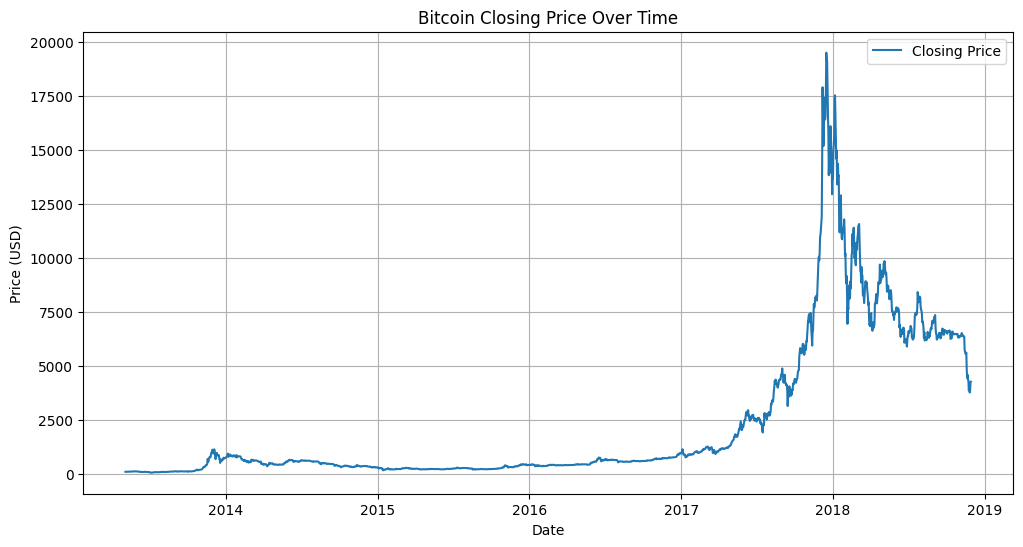

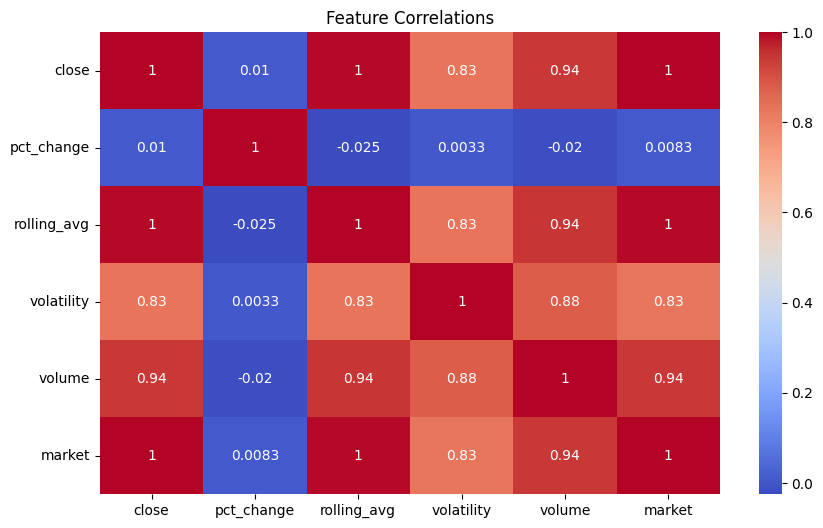

ADF Statistic: -2.005893995067566
p-value: 0.28399478253408905
The data is non-stationary.


In [4]:

# 3. Exploratory Data Analysis (EDA)
# Add Derived Features
bitcoin_data['pct_change'] = bitcoin_data['close'].pct_change()
bitcoin_data['rolling_avg'] = bitcoin_data['close'].rolling(window=7).mean()
bitcoin_data['volatility'] = bitcoin_data['close'].rolling(window=7).std()
bitcoin_data = bitcoin_data.dropna()

# Visualize the Data: Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(bitcoin_data['date'], bitcoin_data['close'], label='Closing Price')
plt.title('Bitcoin Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

# Heatmap for Feature Correlations
plt.figure(figsize=(10, 6))
sns.heatmap(bitcoin_data[['close', 'pct_change', 'rolling_avg', 'volatility', 'volume', 'market']].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlations')
plt.show()

# Check Stationarity
from statsmodels.tsa.stattools import adfuller
result = adfuller(bitcoin_data['close'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])
if result[1] > 0.05:
    print("The data is non-stationary.")
else:
    print("The data is stationary.")


In [5]:

# 4. Preprocessing
# Handle Missing Data: Already addressed with rolling window.
# Resample Data: Not needed for this dataset.
# Make Data Stationary: Applied as needed in ARIMA models.

# 5. Model Selection
# Split the dataset for ARIMA (train/test split)
train_size = int(len(bitcoin_data) * 0.8)
train_data = bitcoin_data['close'][:train_size]
test_data = bitcoin_data['close'][train_size:]

# Correct ARIMA: Expanded Parameter Grid
p = d = q = range(0, 3)  # Expanded range for ARIMA parameters
params = list(product(p, d, q))
best_aic = float('inf')
best_params = None

for param in params:
    try:
        model = SARIMAX(train_data, order=param)
        result = model.fit(disp=False)
        if result.aic < best_aic:
            best_aic = result.aic
            best_params = param
    except:
        continue

# Fit the Best ARIMA Model
arima_model = SARIMAX(train_data, order=best_params)
arima_fitted = arima_model.fit()

# Forecast for the Test Period
forecast = arima_fitted.forecast(steps=len(test_data))
forecast_values = forecast

# Calculate ARIMA Metrics
rmse_arima = np.sqrt(mean_squared_error(test_data, forecast_values))
mae_arima = mean_absolute_error(test_data, forecast_values)
r2_arima = r2_score(test_data, forecast_values)
accuracy_arima = r2_arima * 100

# Align forecast index with test data
forecast_index = test_data.index  # Ensure the forecast index matches the test data index
forecast_values.index = forecast_index  # Align indices


C:\Users\RASHI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\RASHI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\RASHI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, 

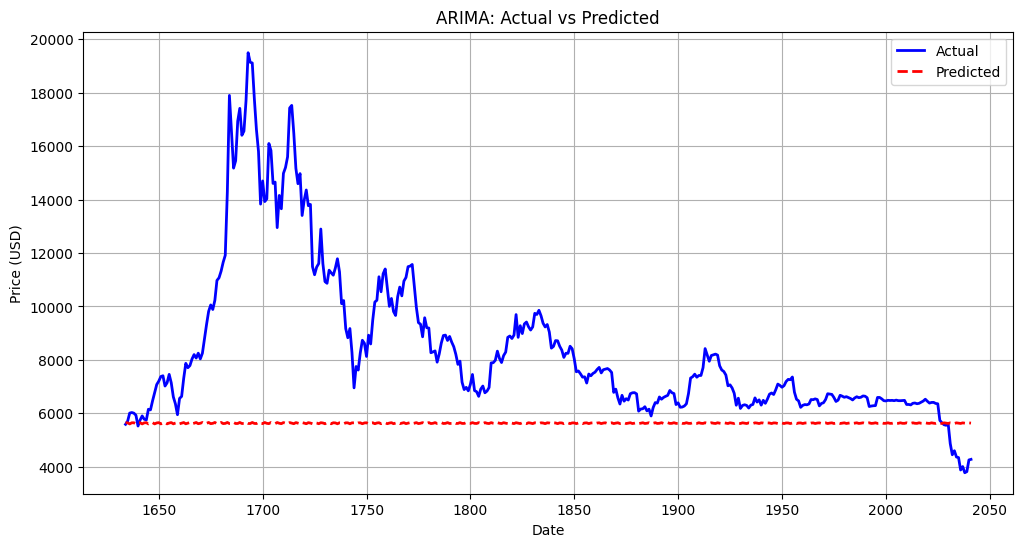

In [6]:

# Plot ARIMA Actual vs Predicted
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, test_data.values, label='Actual', color='blue', linewidth=2)
plt.plot(forecast_index, forecast_values, label='Predicted', color='red', linestyle='--', linewidth=2)
plt.title('ARIMA: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

# Prepare Features and Target
features = bitcoin_data[['volume', 'market', 'pct_change', 'rolling_avg', 'volatility']]
target = bitcoin_data['close']
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
X_train, X_test, y_train, y_test = train_test_split(features_scaled, target, test_size=0.2, random_state=42)

# Train Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

# Calculate Linear Regression Metrics
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
mae_linear = mean_absolute_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)
accuracy_linear = r2_linear * 100


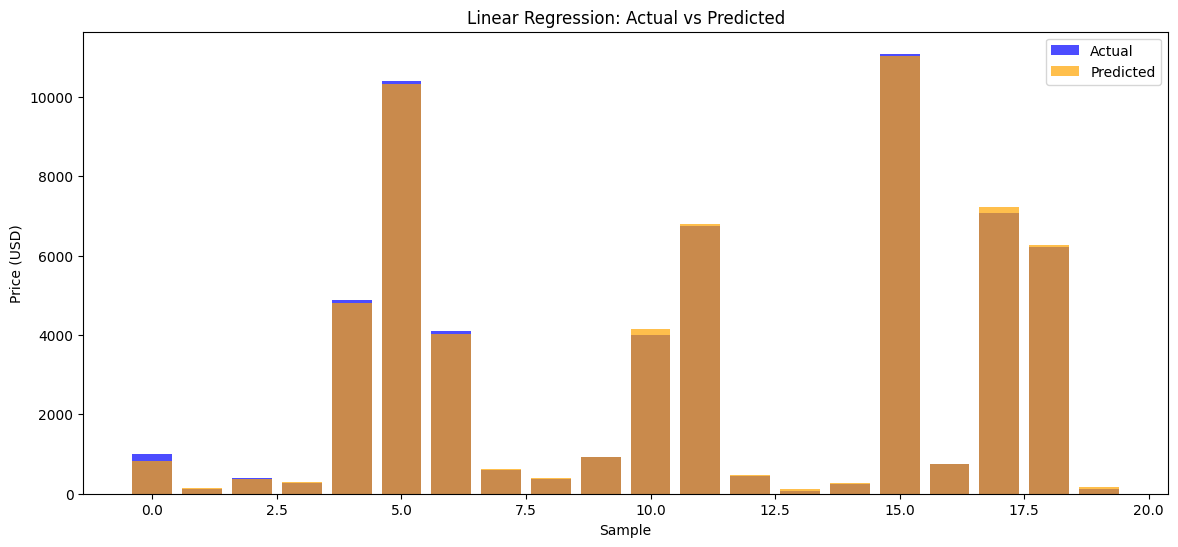

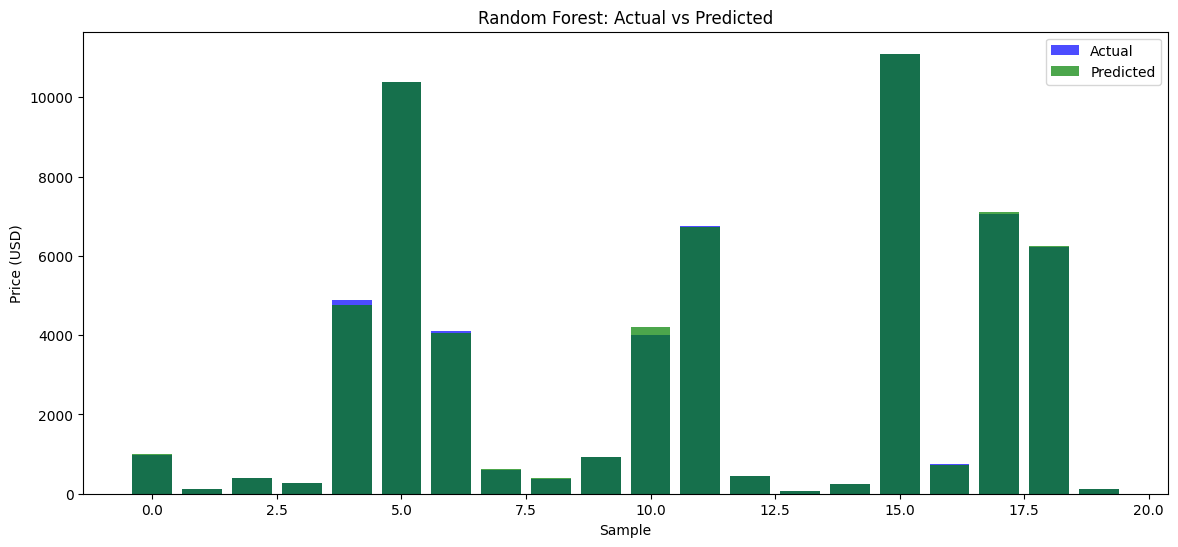

In [7]:

# Visualize Linear Regression Predictions
plt.figure(figsize=(14, 6))
plt.bar(range(20), y_test[:20], alpha=0.7, label='Actual', color='blue')
plt.bar(range(20), y_pred_linear[:20], alpha=0.7, label='Predicted', color='orange')
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Sample')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

# Random Forest with Hyperparameter Tuning
rf_model = RandomForestRegressor(random_state=42)
param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [10, 20, None]}
rf_tuned = GridSearchCV(rf_model, param_grid, cv=3)
rf_tuned.fit(X_train, y_train)
y_pred_rf = rf_tuned.best_estimator_.predict(X_test)

# Calculate Random Forest Metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
accuracy_rf = r2_rf * 100

# Visualize Random Forest Predictions
plt.figure(figsize=(14, 6))
plt.bar(range(20), y_test[:20], alpha=0.7, label='Actual', color='blue')
plt.bar(range(20), y_pred_rf[:20], alpha=0.7, label='Predicted', color='green')
plt.title('Random Forest: Actual vs Predicted')
plt.xlabel('Sample')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()


C:\Users\RASHI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 1.4926e-04 - val_loss: 3.0871e-04
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 1.7303e-05 - val_loss: 3.3301e-04
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 1.2079e-05 - val_loss: 4.2608e-04
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 1.0849e-05 - val_loss: 3.9399e-04
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 8.2965e-06 - val_loss: 3.8859e-04
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 7.4998e-06 - val_loss: 3.8669e-04
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 6.8097e-06 - val_loss: 3.5774e-04
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 9.6726e-06 - val_loss: 1.9236e-04
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 6.8152e-06 - val_loss: 2.8549e-04
Epoch 10/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 7.8569e-06 - val_loss: 1.3602e-04
Epoch 11/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 6.0134e-0

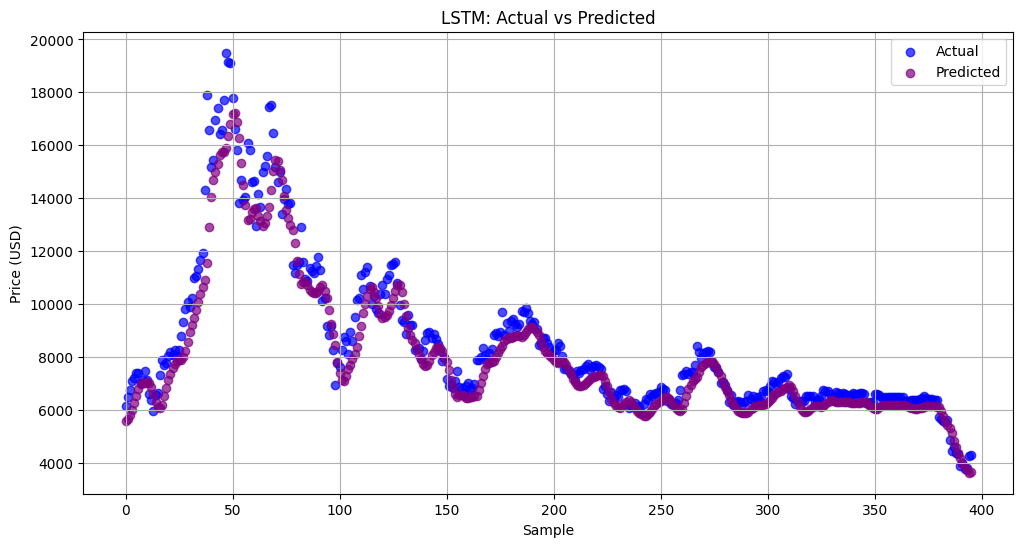

In [8]:

# Prepare Data for LSTM
scaler_lstm = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler_lstm.fit_transform(bitcoin_data[['close']])

lookback = 60
X_lstm, y_lstm = [], []
for i in range(lookback, len(scaled_data)):
    X_lstm.append(scaled_data[i - lookback:i, 0])
    y_lstm.append(scaled_data[i, 0])

X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)
split = int(len(X_lstm) * 0.8)
X_train_lstm, X_test_lstm = X_lstm[:split], X_lstm[split:]
y_train_lstm, y_test_lstm = y_lstm[:split], y_lstm[split:]

X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0], X_train_lstm.shape[1], 1))
X_test_lstm = X_test_lstm.reshape((X_test_lstm.shape[0], X_test_lstm.shape[1], 1))

# Train LSTM Model
lstm_model = Sequential()
lstm_model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(units=50, return_sequences=False))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(units=25))
lstm_model.add(Dense(units=1))
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

lstm_model.fit(X_train_lstm, y_train_lstm, epochs=50, validation_split=0.2, batch_size=32, verbose=1)

# Predictions for LSTM
y_pred_lstm = lstm_model.predict(X_test_lstm)
y_pred_lstm_rescaled = scaler_lstm.inverse_transform(y_pred_lstm.reshape(-1, 1))
y_test_lstm_rescaled = scaler_lstm.inverse_transform(y_test_lstm.reshape(-1, 1))

# Calculate LSTM Metrics
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm_rescaled, y_pred_lstm_rescaled))
mae_lstm = mean_absolute_error(y_test_lstm_rescaled, y_pred_lstm_rescaled)
r2_lstm = r2_score(y_test_lstm_rescaled, y_pred_lstm_rescaled)
accuracy_lstm = r2_lstm * 100

# Visualize LSTM Predictions
plt.figure(figsize=(12, 6))
plt.scatter(range(len(y_test_lstm_rescaled)), y_test_lstm_rescaled, label='Actual', color='blue', alpha=0.7)
plt.scatter(range(len(y_pred_lstm_rescaled)), y_pred_lstm_rescaled, label='Predicted', color='purple', alpha=0.7)
plt.title('LSTM: Actual vs Predicted')
plt.xlabel('Sample')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()


In [9]:

# Ensemble Learning and Final Comparison
min_length = min(len(y_test), len(y_pred_rf), len(y_pred_lstm_rescaled))
y_test_trimmed = y_test.iloc[-min_length:]
y_pred_rf_trimmed = y_pred_rf[-min_length:]
y_pred_lstm_rescaled_trimmed = y_pred_lstm_rescaled.flatten()[-min_length:]

# Normalize predictions
rf_min, rf_max = y_pred_rf_trimmed.min(), y_pred_rf_trimmed.max()
lstm_min, lstm_max = y_pred_lstm_rescaled_trimmed.min(), y_pred_lstm_rescaled_trimmed.max()

# Rescale back to original range
ensemble_predictions = ((y_pred_rf_trimmed - rf_min) / (rf_max - rf_min) + 
                        (y_pred_lstm_rescaled_trimmed - lstm_min) / (lstm_max - lstm_min)) / 2
ensemble_predictions = ensemble_predictions * (rf_max - rf_min) + rf_min

# Ensemble Metrics
rmse_ensemble = np.sqrt(mean_squared_error(y_test_trimmed, ensemble_predictions))
mae_ensemble = mean_absolute_error(y_test_trimmed, ensemble_predictions)
r2_ensemble = r2_score(y_test_trimmed, ensemble_predictions)
accuracy_ensemble = max(0, r2_ensemble * 100)

# Display Metrics
print(f"Ensemble RMSE: {rmse_ensemble:.2f}")
print(f"Ensemble MAE: {mae_ensemble:.2f}")
print(f"Ensemble R²: {r2_ensemble:.4f}")
print(f"Ensemble Accuracy: {accuracy_ensemble:.2f}%")


Ensemble RMSE: 2970.72
Ensemble MAE: 2453.32
Ensemble R²: 0.2921
Ensemble Accuracy: 29.21%


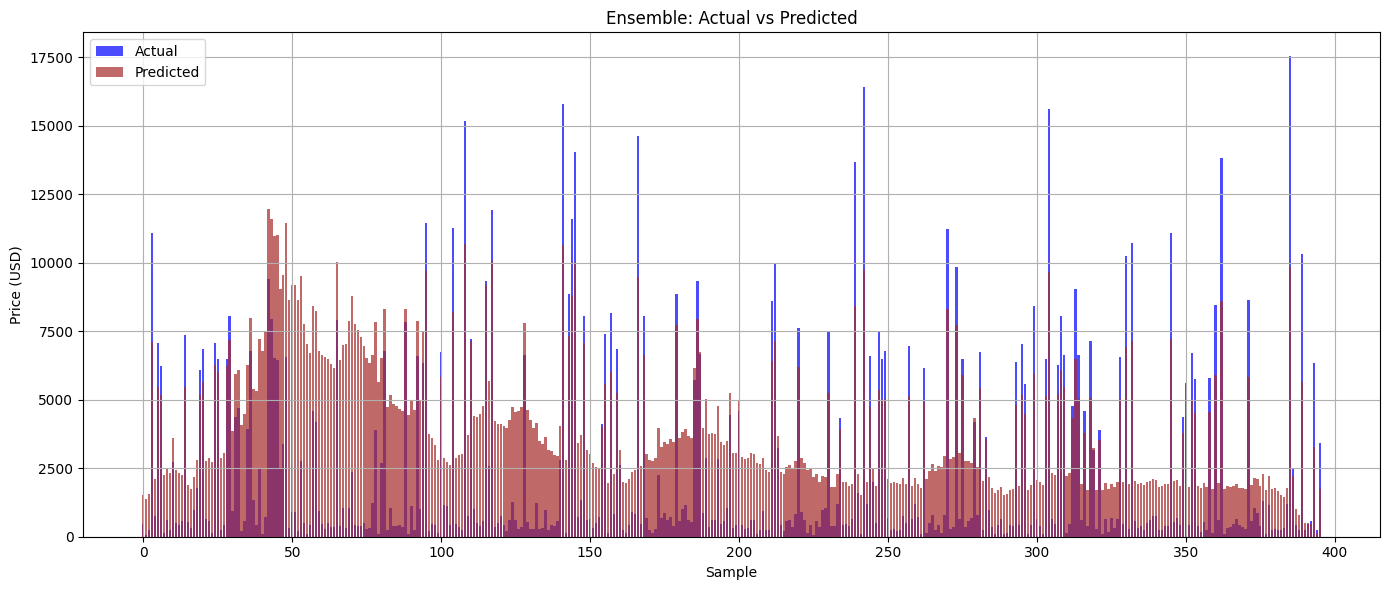

In [10]:

# Visualize Ensemble Predictions
plt.figure(figsize=(14, 6))
indices = range(len(y_test_trimmed))
plt.bar(indices, y_test_trimmed.values, alpha=0.7, label='Actual', color='blue')
plt.bar(indices, ensemble_predictions, alpha=0.7, label='Predicted', color='brown')
plt.title('Ensemble: Actual vs Predicted')
plt.xlabel('Sample')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Model Performance Comparison:
               Model         RMSE          MAE        R²  Accuracy (%)
0              ARIMA  4050.343931  2863.702105 -0.899344    -89.934402
1  Linear Regression    67.609863    48.057158  0.999631     99.963114
2      Random Forest    53.540047    26.599626  0.999769     99.976869
3               LSTM   906.103792   625.581985  0.905532     90.553155
4           Ensemble  2970.723199  2453.317946  0.292141     29.214136


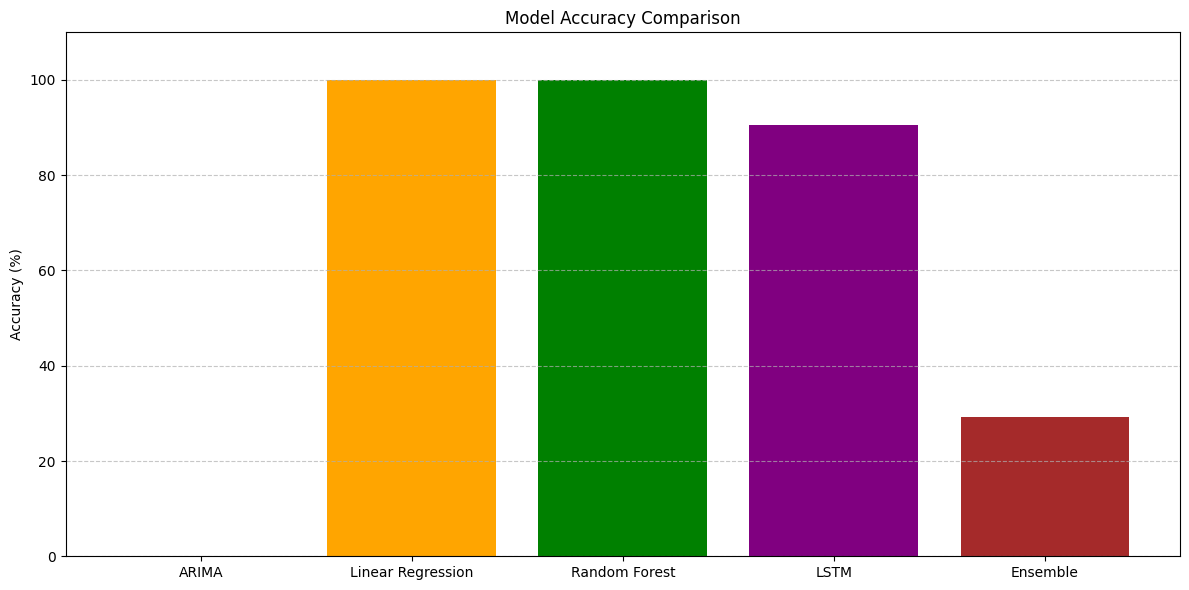

In [11]:
# Metrics for each model
model_metrics = {
    'Model': ['ARIMA', 'Linear Regression', 'Random Forest', 'LSTM', 'Ensemble'],
    'RMSE': [rmse_arima, rmse_linear, rmse_rf, rmse_lstm, rmse_ensemble],
    'MAE': [mae_arima, mae_linear, mae_rf, mae_lstm, mae_ensemble],
    'R²': [r2_arima, r2_linear, r2_rf, r2_lstm, r2_ensemble],
    'Accuracy (%)': [accuracy_arima, accuracy_linear, accuracy_rf, accuracy_lstm, accuracy_ensemble]
}

# Create a DataFrame for better visualization
comparison_df = pd.DataFrame(model_metrics)

# Print the comparison DataFrame
print("\nModel Performance Comparison:")
print(comparison_df)

# Visualize Model Accuracy Comparison
plt.figure(figsize=(12, 6))
plt.bar(comparison_df['Model'], comparison_df['Accuracy (%)'], color=['blue', 'orange', 'green', 'purple', 'brown'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Cross-Validation and Parameter Tuning

In [24]:
from sklearn.model_selection import cross_val_score

# Cross-validate Linear Regression
cv_scores_linear = cross_val_score(linear_model, X_train, y_train, cv=5, scoring='r2')
print(f"Cross-Validation Scores for Linear Regression: {cv_scores_linear}")
print(f"Average R² from Cross-Validation: {np.mean(cv_scores_linear):.4f}")

# Cross-validate Random Forest
cv_scores_rf = cross_val_score(rf_tuned.best_estimator_, X_train, y_train, cv=5, scoring='r2')
print(f"Cross-Validation Scores for Random Forest: {cv_scores_rf}")
print(f"Average R² from Cross-Validation: {np.mean(cv_scores_rf):.4f}")

# Parameter tuning already included in ARIMA and Random Forest grid search


Cross-Validation Scores for Linear Regression: [0.99961366 0.99961428 0.99964901 0.99969331 0.99971579]
Average R² from Cross-Validation: 0.9997
Cross-Validation Scores for Random Forest: [0.99975943 0.99975421 0.99974011 0.99972973 0.99967336]
Average R² from Cross-Validation: 0.9997


Transformed Linear Regression RMSE: 9017.39
Transformed Linear Regression MAE: 1943.34
Transformed Linear Regression R²: -5.5616


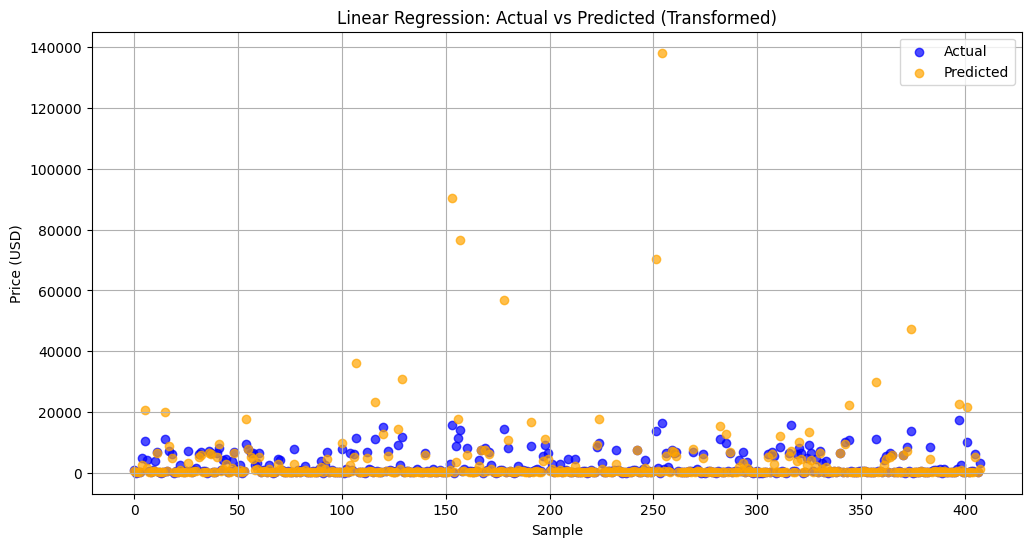

Linear Regression RMSE (No Transformation): 67.61
Linear Regression MAE (No Transformation): 48.06
Linear Regression R² (No Transformation): 0.9996

Comparison of Metrics:
RMSE - Transformed: 9017.39, Non-Transformed: 67.61
MAE - Transformed: 1943.34, Non-Transformed: 48.06
R² - Transformed: -5.5616, Non-Transformed: 0.9996


In [28]:
# Debugging Step 1: Check if target contains non-positive values
if (y_train <= 0).any() or (y_test <= 0).any():
    print("Log transformation is invalid due to non-positive values in the data.")
else:
    # Apply log transformation
    y_train_log = np.log1p(y_train)
    y_test_log = np.log1p(y_test)

    # Train Linear Regression Model on Transformed Data
    linear_model = LinearRegression()
    linear_model.fit(X_train, y_train_log)
    y_pred_linear_log = linear_model.predict(X_test)

    # Back-transform Predictions
    y_pred_linear_transformed = np.expm1(y_pred_linear_log)

    # Calculate Metrics for Transformed Data
    rmse_linear_transformed = np.sqrt(mean_squared_error(y_test, y_pred_linear_transformed))
    mae_linear_transformed = mean_absolute_error(y_test, y_pred_linear_transformed)
    r2_linear_transformed = r2_score(y_test, y_pred_linear_transformed)

    print(f"Transformed Linear Regression RMSE: {rmse_linear_transformed:.2f}")
    print(f"Transformed Linear Regression MAE: {mae_linear_transformed:.2f}")
    print(f"Transformed Linear Regression R²: {r2_linear_transformed:.4f}")

    # Visualize Predictions After Back-Transformation
    plt.figure(figsize=(12, 6))
    plt.scatter(range(len(y_test)), y_test, alpha=0.7, label='Actual', color='blue')
    plt.scatter(range(len(y_pred_linear_transformed)), y_pred_linear_transformed, alpha=0.7, label='Predicted', color='orange')
    plt.title('Linear Regression: Actual vs Predicted (Transformed)')
    plt.xlabel('Sample')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Debugging Step 2: Train and Evaluate Without Transformation
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
mae_linear = mean_absolute_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"Linear Regression RMSE (No Transformation): {rmse_linear:.2f}")
print(f"Linear Regression MAE (No Transformation): {mae_linear:.2f}")
print(f"Linear Regression R² (No Transformation): {r2_linear:.4f}")

# Compare Transformed and Non-Transformed Results
print("\nComparison of Metrics:")
print(f"RMSE - Transformed: {rmse_linear_transformed:.2f}, Non-Transformed: {rmse_linear:.2f}")
print(f"MAE - Transformed: {mae_linear_transformed:.2f}, Non-Transformed: {mae_linear:.2f}")
print(f"R² - Transformed: {r2_linear_transformed:.4f}, Non-Transformed: {r2_linear:.4f}")


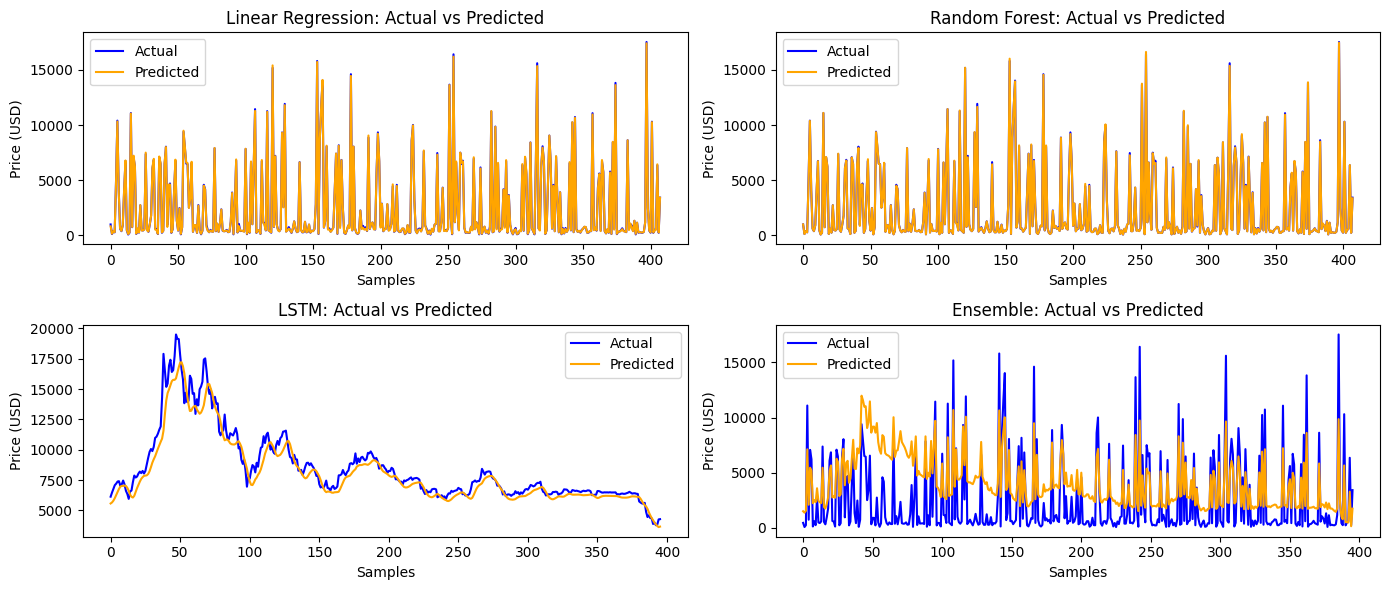

In [14]:
# Compare Actual vs. Predicted for all models
models = ['Linear Regression', 'Random Forest', 'LSTM', 'Ensemble']
actual_values = [y_test, y_test, y_test_lstm_rescaled, y_test_trimmed]
predicted_values = [y_pred_linear, y_pred_rf, y_pred_lstm_rescaled, ensemble_predictions]

plt.figure(figsize=(14, 6))
for i, (model, actual, predicted) in enumerate(zip(models, actual_values, predicted_values)):
    plt.subplot(2, 2, i + 1)
    plt.plot(range(len(actual)), actual[:len(predicted)], label='Actual', color='blue')
    plt.plot(range(len(predicted)), predicted, label='Predicted', color='orange')
    plt.title(f"{model}: Actual vs Predicted")
    plt.xlabel('Samples')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.tight_layout()
plt.show()
